# LangChain Agent Runtime with Groq

This notebook introduces the high-level LangChain agent runtime: how to connect to a model, define tools, and let the runtime decide when a tool is needed.

The resulting agent can use tools, return a message trace, and keep short-term memory across several calls.

> [!NOTE]
> This is the same agent loop you built by hand in notebook 1, now run for you by LangChain's `create_agent(...)`. The loop itself (call the model, run any requested tools, feed the results back, repeat) is unchanged, so skim those parts quickly. Focus instead on what the framework adds on top: tool definitions with `@tool`, readable message traces, and checkpoint-backed memory.

## Learning Objectives

At the end of this notebook, you should be able to:

- Build a tool-using agent with LangChain's high-level `create_agent(...)` runtime.
- Inspect an agent's message trace to follow each model step, tool call, and tool result.
- Compare a plain LLM call with an agent run and explain what the runtime loop adds.
- Add short-term memory to an agent using a checkpointer and a `thread_id`.

## Agent workflow summary

```mermaid
flowchart TD
    A["User message"] --> B["LangChain agent runtime"]
    B --> C{"Model needs a tool?"}

    C -->|No| D["Final AIMessage"]
    D --> E["Answer shown to user"]

    C -->|Yes| F["Model emits tool call(s)"]
    F --> G["Runtime maps tool names to Python functions"]
    G --> H["Tool executes in Python"]
    H --> I["Tool result added as ToolMessage"]
    I --> J["Conversation history updates"]
    J --> B

    J --> K["Trace shows: Human → AI → Tool → Final AI"]

    L["checkpointer + thread_id"] --> M{"Same thread?"}
    M -->|Yes| N["Load previous conversation memory"]
    M -->|No| O["Start with a fresh thread"]
    N --> B
    O --> B
```

This diagram summarizes the key idea in the notebook: the model decides whether it needs a tool, the runtime executes it, the result is fed back into the conversation, and memory is tracked by thread ID so separate conversations stay separated.

## Agent flow at a glance

```mermaid
flowchart TD
    A["User message"] --> B["LangChain agent runtime"]
    B --> C{"Model needs a tool?"}

    C -->|No| D["Final AIMessage"]
    D --> E["Answer shown to user"]

    C -->|Yes| F["Model emits tool call(s)"]
    F --> G["Runtime maps tool name to Python function"]
    G --> H["Tool executes in Python"]
    H --> I["Tool result added as ToolMessage"]
    I --> J["Message history updates"]
    J --> B

    J --> K["Trace shows: Human → AI → Tool → Final AI"]

    L["checkpointer + thread_id"] --> M{"Same thread?"}
    M -->|Yes| N["Load previous conversation memory"]
    M -->|No| O["Start with a fresh thread"]
    N --> B
    O --> B
```

## How LangChain agents work

With `create_agent(...)`, you give LangChain three things:

- a **model** (the LLM)
- a list of **tools**
- a **system prompt** (instructions for how the agent should behave)

LangChain then takes care of the rest. It runs a loop where the model can decide step by step what to do.

```mermaid
flowchart TD
    Q["User message"] --> D{"Model decides"}
    D -->|can answer directly| F["Final response"]
    D -->|needs help| C["Call a tool"]
    C --> X["Tool runs in Python"]
    X --> O["Result added to the conversation"]
    O --> D
```

[See the full agent loop diagram in the official LangChain docs](https://docs.langchain.com/oss/python/langchain/agents)

### What happens inside the agent

At a high level, the loop works like this:

1. The **model reads the user message**
2. It decides:
   - can I answer directly? then return a response
   - do I need help? then call a tool
3. If a tool is used:
   - the tool runs in Python
   - the result is added back into the conversation
4. The model sees the new information and continues

This repeats until the model produces a final answer.

### Where custom logic fits

Between the model and the tools, LangChain can apply extra logic (middleware) such as:

- adjusting prompts
- adding safety checks
- deciding which tools are allowed

```mermaid
flowchart LR
    M["Model"] --> MW["Middleware:<br/>prompts, safety checks, tool gating"]
    MW --> T["Tools"]
    T --> MW
    MW --> M
```

You do not need to configure this to get started. `create_agent(...)` already provides a working default.

[See the middleware diagram in the official LangChain docs](https://docs.langchain.com/oss/python/langchain/agents)

A useful separation is:

- the **model** produces messages and tool-call requests
- the **tool** is normal application code that can calculate, fetch, or transform data
- the **runtime** coordinates the loop: it sends messages to the model, runs requested tools, appends tool results, and asks the model to continue

This separation is what makes an agent more than a single LLM call. The model decides what should happen next, but the application runtime performs the actual tool execution.


## From message to answer

The model reasons over the conversation, emits tool calls when they are needed, receives the results back as messages, and produces a final answer. Everything in this notebook fits inside that single loop, which LangChain runs on top of LangGraph.

In [1]:
from dotenv import load_dotenv  # read secret keys from a .env file
from IPython.display import Image, display  # show images inside the notebook
from langchain.agents import create_agent  # build a LangChain agent
from langchain.chat_models import (
    init_chat_model,
)  # choose and connect to an AI model (e.g. GPT)
from langchain.tools import tool  # turn a regular Python function into an agent tool
from langchain_core.runnables import (
    RunnableConfig,
)  # extra options you can pass when running the agent
from langgraph.checkpoint.memory import (
    InMemorySaver,
)  # save agent state to enable memory

## Initialize the model

`init_chat_model(...)` connects your code to a language model (LLM).

The interface is **provider-agnostic**, so you can switch between providers like Groq, OpenAI, or Anthropic without changing your code.

We set `temperature=0` to make the model **more consistent** and reduce randomness. Outputs are usually similar for the same input, which makes examples easier to compare.

In [2]:
# Load provider credentials from the local .env file.
load_dotenv(".env")

# A deterministic temperature keeps examples easier to compare across runs.
model = init_chat_model(
    "groq:openai/gpt-oss-20b",
    temperature=0,
)
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002BD11137CB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002BD112ECAD0>, model_name='openai/gpt-oss-20b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

---

## Regular LLM call vs agent

**Regular LLM call**  
- one input → one output  
- no tools  
- no loop  
- no memory (unless you pass everything manually)

**Agent**  
- wraps the model in a loop  
- can call tools and use their results  
- repeats steps until the task is done  
- can keep memory across multiple calls

```mermaid
flowchart LR
    U1["User input"] --> LLM["Regular LLM call"] --> R1["Single response"]
    U2["User input"] --> AG["Agent runtime"]
    AG --> M["Model"]
    M -->|optional tool calls| T["Tools"]
    T --> M
    M --> R2["Final response"]
```

The following example runs the prompt with a plain model first. A later agent invocation uses the same prompt shape to show what changes once the runtime can call tools.

In [3]:
# Plain LLM call: one input → one response (no tools, no loop)
plain_llm_result = model.invoke(
    [
        (
            "human",
            "Multiply 8 by 7, then create a slug for 'LangGraph MCP Launch' and count the slug length.",
        )
    ]
)

# Inspect the result: a single AIMessage with generated text
plain_llm_result.content

'- **Multiplication result:** 8 × 7 = **56**\n\n- **Slug for “LangGraph MCP Launch”:** `langgraph-mcp-launch`\n\n- **Slug length:** **20** characters (including the two hyphens)'

l a n g g r a p h - m c p - l a u n c h There are 20 total characters, including the two hyphens.

The model returns a single `AIMessage`. It answers in prose and, because it is guessing rather than running code, it can get the slug length wrong (the exact number varies between runs). There are no tool calls, no intermediate steps, and no memory. The next sections hand the same task to an agent, so the counting is done by a tool instead.

The plain model response may be correct, but the application only gets a single `AIMessage`. There are no intermediate steps, no tool calls, and no built-in memory.

---

## Define tools

The agent setup starts with tools.

Tools are regular Python functions marked with `@tool`.

The decorator turns each function into a description the model can use.  
It reads:
- the **function name**  
- the **arguments** (from the signature)  
- the **description** (from the docstring)  

Based on this, the model can decide which tool to call and what arguments to pass.  
The tool runs in Python, and the result is fed back into the agent loop.

In [4]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


@tool
def string_length(text: str) -> int:
    """Return the number of characters in a string."""
    return len(text)


@tool
def slugify_title(title: str) -> str:
    """Convert a title into a lowercase hyphenated slug."""
    return "-".join(title.lower().split())


tools = [multiply, string_length, slugify_title]
tools

[StructuredTool(name='multiply', description='Multiply two integers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000002BD112947C0>),
 StructuredTool(name='string_length', description='Return the number of characters in a string.', args_schema=<class 'langchain_core.utils.pydantic.string_length'>, func=<function string_length at 0x000002BD11294720>),
 StructuredTool(name='slugify_title', description='Convert a title into a lowercase hyphenated slug.', args_schema=<class 'langchain_core.utils.pydantic.slugify_title'>, func=<function slugify_title at 0x000002BD11294680>)]

## Inspect the tool catalog

Before the agent runs, the model receives a description of all available tools:
- name  
- description  
- expected arguments  

Printing this catalog shows exactly what the model sees.

This is useful for debugging: if the agent picks the wrong tool or uses wrong arguments, the issue is often in the tool description, not the code.

Tool schemas are the contract between the model and the Python function. The tool name and description influence when the model chooses the tool, while the argument schema tells the model which fields it must provide. If an agent calls the wrong tool or passes weak arguments, reviewing this schema is usually the first debugging step.


In [5]:
tool_catalog = {
    tool.name: {
        "description": tool.description,
        "schema": tool.args,
    }
    for tool in tools
}
tool_catalog

{'multiply': {'description': 'Multiply two integers.',
  'schema': {'a': {'title': 'A', 'type': 'integer'},
   'b': {'title': 'B', 'type': 'integer'}}},
 'string_length': {'description': 'Return the number of characters in a string.',
  'schema': {'text': {'title': 'Text', 'type': 'string'}}},
 'slugify_title': {'description': 'Convert a title into a lowercase hyphenated slug.',
  'schema': {'title': {'title': 'Title', 'type': 'string'}}}}

## Build the agent
Now we put everything together to create the agent. We pass the **model**, the **tools**, and a **system_prompt** (instructions) to `create_agent(...)`.
The `system_prompt` is a hidden instruction that guides how the agent should behave (for example, when to use tools).
The result is an agent that can decide when to use tools and produce a final answer.

1. agent.get_graph(...)
This asks the LangChain agent for its internal graph structure.

A graph is the runtime’s workflow:

states
transitions
tools
model calls
loop logic
So this returns a graph object representing the agent.

2. xray=True
This tells LangChain to produce a more detailed, inspectable graph.

It shows the internal steps, not just a simple high-level flow.

3. .draw_mermaid_png()
This converts the graph into a Mermaid diagram image in PNG format.

Mermaid is a diagram language used to render flowcharts.

4. Image(...)
This wraps the PNG data as a notebook image object.

5. display(...) This displays the image directly in the Jupyter notebook cell output.



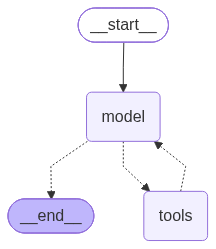

In [6]:
agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=(
        "You are a precise assistant. "
        "Use tools whenever arithmetic, counting, or formatting is involved."
    ),
)

# The returned object is a runnable graph-backed application.
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## Run a tool-heavy request

This is the same prompt as before, but now it is handled by the agent instead of a plain model. Because the agent has access to tools, it can solve the task step by step: call tools, use their results, and continue until it produces a final answer.

The last message in the output contains that final answer.

In [7]:
tool_result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Multiply 8 by 7, then create a slug for 'LangGraph MCP Launch' and count the slug length."
                ),
            }
        ]
    }
)

tool_result["messages"][-1].content

'- 8 × 7 = **56**  \n- Slug for “LangGraph MCP Launch”: **langgraph-mcp-launch**  \n- Length of the slug: **20** characters'

This time the agent used its tools. It multiplied with `multiply` (56), created the slug with `slugify_title` (`langgraph-mcp-launch`), and counted the characters with `string_length` (20). The count is now correct because a tool computed it, not the model: `string_length` returns the real length every time, whereas the plain model earlier had to guess at it.

## Inspect the message trace
LangChain returns a dictionary with a `messages` field that contains all steps of the agent run. This lets you see what happened step by step: model responses, tool calls, and their results. The helper function below formats this into a simple list that is easier to read.

In [8]:
def summarize_messages(messages):
    # Keep the trace compact so tool calls and tool results are easy to scan.
    rows = []
    for index, message in enumerate(messages):
        rows.append(
            {
                "index": index,
                "type": type(message).__name__,
                "content": getattr(message, "content", None),
                "tool_calls": getattr(message, "tool_calls", None),
            }
        )
    return rows

In [9]:
summarize_messages(tool_result["messages"])

[{'index': 0,
  'type': 'HumanMessage',
  'content': "Multiply 8 by 7, then create a slug for 'LangGraph MCP Launch' and count the slug length.",
  'tool_calls': None},
 {'index': 1,
  'type': 'AIMessage',
  'content': '',
  'tool_calls': [{'name': 'multiply',
    'args': {'a': 8, 'b': 7},
    'id': 'fc_f64b5cd6-c5bf-45b2-84cf-b3468bed0cfc',
    'type': 'tool_call'}]},
 {'index': 2, 'type': 'ToolMessage', 'content': '56', 'tool_calls': None},
 {'index': 3,
  'type': 'AIMessage',
  'content': '',
  'tool_calls': [{'name': 'slugify_title',
    'args': {'title': 'LangGraph MCP Launch'},
    'id': 'fc_7e56f5a0-c4d8-4277-a371-5f5133b4fa40',
    'type': 'tool_call'}]},
 {'index': 4,
  'type': 'ToolMessage',
  'content': 'langgraph-mcp-launch',
  'tool_calls': None},
 {'index': 5,
  'type': 'AIMessage',
  'content': '',
  'tool_calls': [{'name': 'string_length',
    'args': {'text': 'langgraph-mcp-launch'},
    'id': 'fc_55802f99-fb7b-4565-be25-e9822b0afef4',
    'type': 'tool_call'}]},
 {'in

The trace makes the loop visible. The first `AIMessage` carries three tool calls (`multiply`, `slugify_title`, and `string_length`) with the arguments the model chose. Each `ToolMessage` returns one result (for example `56`), and the final `AIMessage` combines them into the answer. When you debug an agent, this trace is where you check which tool ran and with what arguments.

## Direct responses without tools
Tool use is optional. If the model can answer directly, the agent skips tools and responds immediately. In this case, the message trace is much shorter: just a `HumanMessage` and a single `AIMessage`.

In [10]:
direct_result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "In one sentence, explain when an agent should call a tool.",
            }
        ]
    }
)

direct_result["messages"][-1].content

'An agent should call a tool whenever it needs to perform a specific operation—such as arithmetic, counting, or formatting—that the tool is designed to handle, rather than attempting to compute or format it manually.'

In [11]:
summarize_messages(direct_result["messages"])

[{'index': 0,
  'type': 'HumanMessage',
  'content': 'In one sentence, explain when an agent should call a tool.',
  'tool_calls': None},
 {'index': 1,
  'type': 'AIMessage',
  'content': 'An agent should call a tool whenever it needs to perform a specific operation—such as arithmetic, counting, or formatting—that the tool is designed to handle, rather than attempting to compute or format it manually.',
  'tool_calls': []}]

## Short-term memory
Agents can remember information across multiple calls. To enable this, we need two things:
- a `checkpointer` (here `InMemorySaver`) to store the conversation
- a `thread_id` to identify which conversation to continue
The checkpointer saves the state after each run, and the `thread_id` tells the agent which memory to load.

The model itself does not permanently remember earlier notebook cells. The checkpointer stores conversation state outside the model and reloads that state when the same `thread_id` is used again. Changing the `thread_id` is similar to opening a separate conversation.


In [12]:
memory_agent = create_agent(
    model=model,
    tools=[string_length],
    system_prompt=(
        "You are a precise assistant. Remember useful facts from the conversation. "
        "If a fact is not in the conversation, say that it is unavailable."
    ),
    checkpointer=InMemorySaver(),
)

primary_thread: RunnableConfig = {
    "configurable": {"thread_id": "langchain-runtime-primary"}
}
secondary_thread: RunnableConfig = {
    "configurable": {"thread_id": "langchain-runtime-secondary"}
}

## Test memory across threads
We first store a fact in the **primary thread**. Then we ask a follow-up question on the same thread and on a different thread. The same thread can reuse the stored fact, while the other thread starts without that memory. This shows that memory is tied to the `thread_id`.


In [13]:
_ = memory_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Remember that the release codename is Atlas. "
                    "Also tell me how many characters are in the word notebook."
                ),
            }
        ]
    },
    config=primary_thread,
)

In [14]:
same_thread = memory_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the release codename, and how many characters are in it?",
            }
        ]
    },
    config=primary_thread,
)

fresh_thread = memory_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the release codename? If it is unavailable, say that it is unavailable.",
            }
        ]
    },
    config=secondary_thread,
)

{
    "same_thread": same_thread["messages"][-1].content,
    "fresh_thread": fresh_thread["messages"][-1].content,
}

{'same_thread': 'The release codename is **Atlas**, which contains **5** characters.',
 'fresh_thread': 'The release codename is unavailable.'}

The same thread remembers: it recalls the codename `Atlas` and reports its length as 5. The fresh thread, which uses a different `thread_id`, has no access to that fact and reports it as unavailable. Memory is tied to the `thread_id`, not to the Python `memory_agent` object.


## Takeaway
`create_agent(...)` is a good starting point when you want tool use, message traces, and memory without building the loop yourself. In the next notebook, we move one level lower and build the same idea directly with LangGraph's graph API.

Different threads are required because memory is scoped to the conversation, not globally to the agent.

Why separate threads matter
A thread_id acts like a conversation ID.

Same thread_id = same conversation memory
Different thread_id = different conversation memory
So this:
config={"configurable": {"thread_id": "langchain-runtime-primary"}}
stores one conversation history.

And this:
config={"configurable": {"thread_id": "langchain-runtime-secondary"}}
stores a completely separate one.

Why you start with a fresh thread
A fresh thread is useful because it gives you a clean baseline.

If you reuse an old thread, the agent may remember earlier facts and answer differently. That is sometimes desirable, but not always.

For example:

If you ask in one thread:
“Remember that the release codename is Atlas.”
Then in the same thread:
“What is the release codename?”
the agent can answer correctly.
But in a new thread, there is no stored memory yet, so the correct behavior is:

“The release codename is unavailable.”
This is important because it shows that memory is not implicit. It must be explicitly associated with a thread.